In [1]:
import pandas as pd #manipulation
import numpy as np  #numerical python
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.preprocessing import StandardScaler  #for rescaling
from sklearn.preprocessing import LabelEncoder   #encoding the data
from sklearn.model_selection import train_test_split  #for splitting the data into training and testing
from sklearn.metrics import *  # for whole evaluation metrics

In [3]:
df = pd.read_csv('E:/credit_card_FD/credit_card_DT.csv')#loading the data

In [88]:
df.head()

,step,city,transaction_type,amount,sender_id,sender_old_balance,sender_new_balance,receiver_id,receiver_old_balance,receiver_new_balance,is_fraud
0,1.0,Delhi,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0
1,1.0,Pune,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0
2,1.0,Bangalore,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0
3,1.0,Mumbai,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0
4,1.0,Bangalore,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0


In [89]:
df.shape

(6363120, 11)

In [4]:
df['city'].unique()

<StringArray>
[    'Delhi',      'Pune', 'Bangalore',    'Mumbai',   'Lucknow',    'Nashik',
   'Chennai',   'kolkata',    'Jaipur', 'Hyderabad']
Length: 10, dtype: str

In [5]:
df['transaction_type'].unique()

<StringArray>
['PAYMENT', 'TRANSFER', 'CASH_OUT', nan, 'DEBIT', 'CASH_IN']
Length: 6, dtype: str

In [90]:
df.head(3)

,step,city,transaction_type,amount,sender_id,sender_old_balance,sender_new_balance,receiver_id,receiver_old_balance,receiver_new_balance,is_fraud
0,1.0,Delhi,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0
1,1.0,Pune,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0
2,1.0,Bangalore,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0


In [91]:
df.info()   #data information


<class 'pandas.DataFrame'>
RangeIndex: 6363120 entries, 0 to 6363119
Data columns (total 11 columns):
 #   Column                Dtype  
---  ------                -----  
 0   step                  float64
 1   city                  str    
 2   transaction_type      str    
 3   amount                float64
 4   sender_id             str    
 5   sender_old_balance    float64
 6   sender_new_balance    float64
 7   receiver_id           str    
 8   receiver_old_balance  float64
 9   receiver_new_balance  float64
 10  is_fraud              float64
dtypes: float64(7), str(4)
memory usage: 534.0 MB


All the columns ok with datatype no missmatch

In [92]:
df.isnull().sum()  #checking for null values

step                    127261
city                         0
transaction_type        127265
amount                  127254
sender_id               127264
sender_old_balance      127257
sender_new_balance      127257
receiver_id             127257
receiver_old_balance    127259
receiver_new_balance    127261
is_fraud                127262
dtype: int64

In [93]:
df.duplicated().sum()  #checking for duplicate values

np.int64(500)

In [94]:
df.drop_duplicates(inplace=True)  #dropping the duplicate values

In [95]:
df.describe()  #statistical summary of the data

,step,amount,sender_old_balance,sender_new_balance,receiver_old_balance,receiver_new_balance,is_fraud
count,6.235368e+06,6.235374e+06,6.235368e+06,6.235368e+06,6.235368e+06,6.235368e+06,6.235368e+06
mean,2.434039e+02,1.835278e+05,8.340368e+05,8.552172e+05,1.100695e+06,1.224908e+06,1.294390e-03
std,1.423425e+02,2.013080e+06,2.888748e+06,2.924054e+06,3.400220e+06,3.671672e+06,3.595435e-02
min,1.000000e+00,-1.000000e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338825e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487786e+04,1.420700e+04,0.000000e+00,1.327110e+05,2.145983e+05,0.000000e+00
75%,3.350000e+02,2.087240e+05,1.073090e+05,1.443270e+05,9.430516e+05,1.111878e+06,0.000000e+00
max,7.430000e+02,1.000000e+09,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00


#Time (step)
Range: 1 to 743   743/24  =31 almost one month
Mean: 243
Represents hourly transactions


#Transaction Amount
Mean: 183,525
Median: 74,876
Max: 1,000,000,000 (very high outliers)
Min: -1000 (invalid value )


##Sender Balance

#sender_old_balance
Mean: 834,035
Median: 14,207
Max: 590000000 (outliers)
Min: 0

#sender_new_balance
Mean: 855,216
Median: 0
Max: 49,585,040 (outliers)
Min: 0

Large difference between mean & median 
skewed data
Many transactions with zero balance after transaction


##Receiver Balance

#receiver_old_balance
Mean: 1100000
Median: 132,712
max : 49,585,040 (outlier)
min : 0


#receiver_new_balance
Mean: 1220000 
Median:214,598
max: 356,179,300   (outlier)
min:0
A some of transactions have extremely high values, which significantly increase the mean compared to the median.
data is skewed 


#Target Variable 
Mean: 0.00129 (0.13%)

Dataset is highly imbalanced
Fraud cases are very rare
Fraud cases < 1%
So Need   SMOTE / undersampling


Outliers Present
Amount and balances have extreme values

Data Quality Issues
Negative transaction amount

Skewed Distributions
Mean > Median

Zero Balance Patterns
Many sender balances become zero







In [96]:
df.describe(include='str')

,city,transaction_type,sender_id,receiver_id
count,6362620,6235368,6235369,6235369
unique,10,5,6226375,2676842
top,kolkata,CASH_OUT,,C1286084959
freq,637568,2192600,13,109


The sender_id column contains blank or missing values that appear multiple times (around 13 occurrences). These represent data quality issues and were handled during preprocessing.

The receiver_id column shows that certain IDs appear multiple times, with one receiver ID (e.g., C1286084959) occurring most frequently (109 times). This suggests that some accounts are involved in multiple transactions.


In [97]:
df.drop(columns=['sender_id', 'receiver_id'], inplace=True)

The sender_id and receiver_id columns were removed during preprocessing as they are high-cardinality identifier features. These columns contain a large number of unique values and do not contribute meaningful patterns for model learning. Including such features can introduce noise, increase model complexity, and potentially lead to overfitting. Therefore, they were excluded to improve model performance and generalization.

In [98]:
df.head(30)

,step,city,transaction_type,amount,sender_old_balance,sender_new_balance,receiver_old_balance,receiver_new_balance,is_fraud
0,1.0,Delhi,PAYMENT,9839.64,170136.00,160296.36,0.0,0.00,0.0
1,1.0,Pune,PAYMENT,1864.28,21249.00,19384.72,0.0,0.00,0.0
2,1.0,Bangalore,TRANSFER,181.00,181.00,0.00,0.0,0.00,1.0
3,1.0,Mumbai,CASH_OUT,181.00,181.00,0.00,21182.0,0.00,1.0
4,1.0,Bangalore,PAYMENT,11668.14,41554.00,29885.86,0.0,0.00,0.0
5,1.0,Pune,PAYMENT,7817.71,53860.00,46042.29,0.0,0.00,NaN
6,1.0,Lucknow,NaN,7107.77,183195.00,176087.23,0.0,0.00,0.0
7,1.0,Nashik,PAYMENT,7861.64,176087.23,168225.59,0.0,0.00,0.0
8,1.0,Chennai,PAYMENT,4024.36,2671.00,0.00,0.0,0.00,0.0
9,NaN,Bangalore,DEBIT,5337.77,41720.00,36382.23,41898.0,40348.79,0.0


In [99]:
df.isnull().sum()  #checking for null values

step                    127252
city                         0
transaction_type        127252
amount                  127246
sender_old_balance      127252
sender_new_balance      127252
receiver_old_balance    127252
receiver_new_balance    127252
is_fraud                127252
dtype: int64

Filling null values in String Columns


There is no null values in city



so filling transaction type with mode 

In [100]:
df['transaction_type'] = df['transaction_type'].fillna(df['transaction_type'].mode()[0])

In [101]:
df['transaction_type'].isnull().sum()

np.int64(0)

Missing values in numerical features were imputed using the median instead of the mean due to the presence of skewed distributions and extreme outliers. Median provides a more robust measure of central tendency and helps maintain data integrity

We can drop null values but we are filling it with median


In [102]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop('is_fraud')

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [103]:
df.isnull().sum()  #checking for null values

step                         0
city                         0
transaction_type             0
amount                       0
sender_old_balance           0
sender_new_balance           0
receiver_old_balance         0
receiver_new_balance         0
is_fraud                127252
dtype: int64

In [104]:
df['is_fraud'] = df['is_fraud'].fillna(df['is_fraud'].mode()[0])

Filling null values of dependent column with mode 

In [105]:
df.isnull().sum() 

step                    0
city                    0
transaction_type        0
amount                  0
sender_old_balance      0
sender_new_balance      0
receiver_old_balance    0
receiver_new_balance    0
is_fraud                0
dtype: int64

let check for the outliers in data

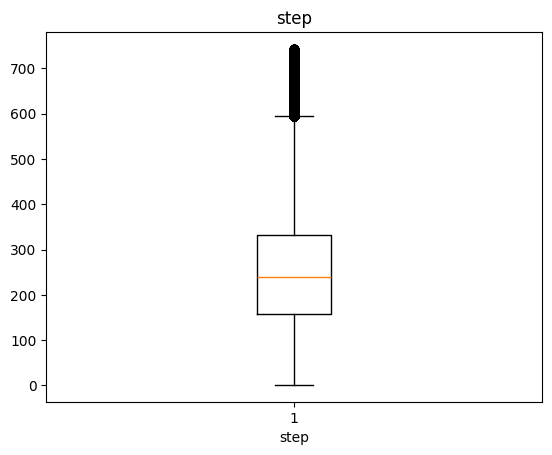

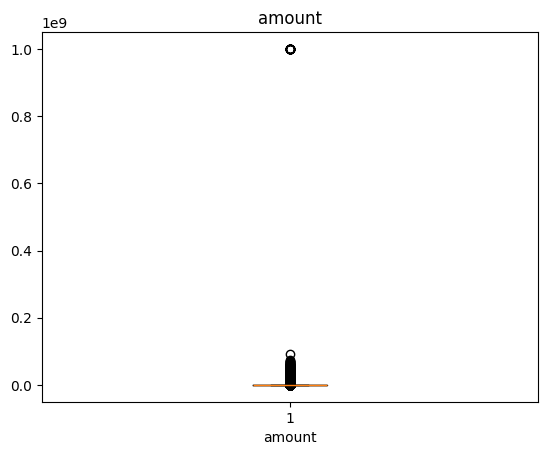

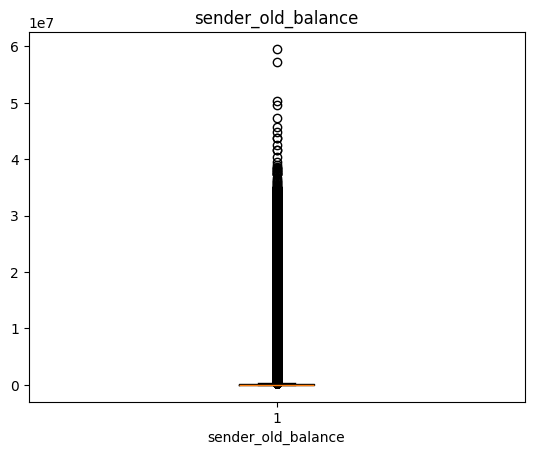

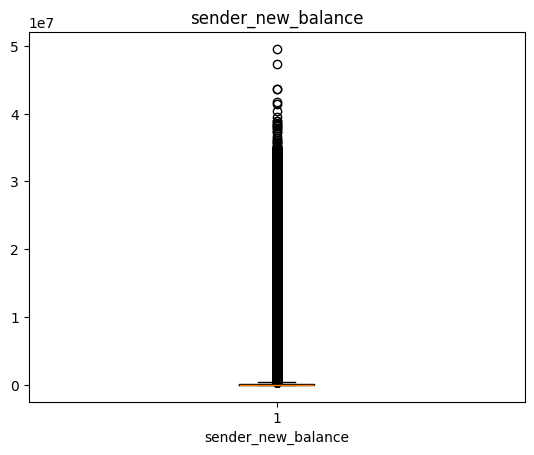

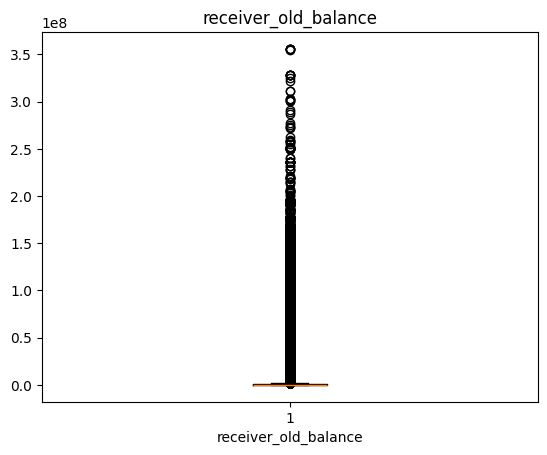

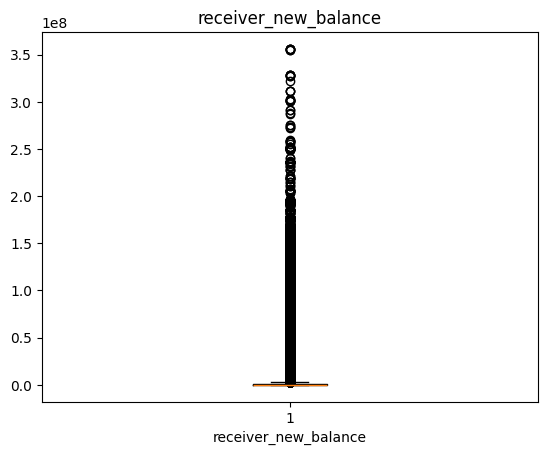

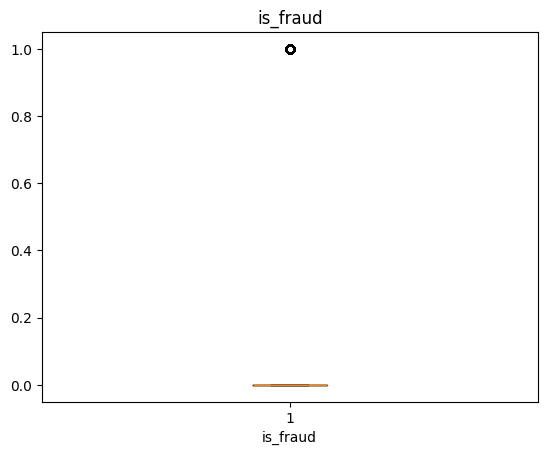

In [106]:
for i in df.columns:
  if df[i].dtypes == df[i].dtypes == 'float64':
    plt.boxplot(df[i])
    plt.xlabel(i)
    plt.title(i)
    plt.show()

The dataset contains significant outliers in the amount column.hese extreme values can disproportionately influence the model and distort the feature distribution.so removing outliers from amount column

In [107]:
Q1 = df['amount'].quantile(0.25)
Q3 = df['amount'].quantile(0.75)
IQR = Q3 - Q1
upper_fence = Q3 + 1.5 * IQR
lower_fence = Q1 - 1.5 * IQR
df = df[ (df['amount'] >= lower_fence) & (df['amount'] <= upper_fence)]

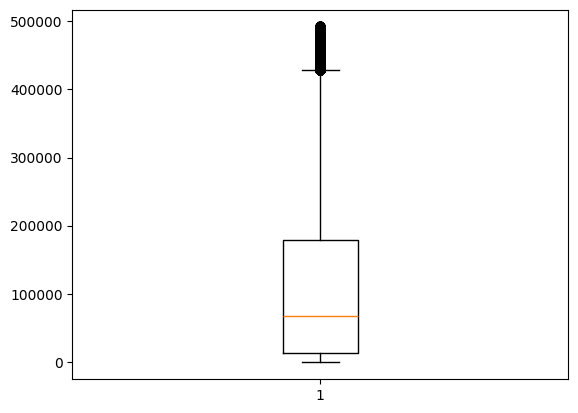

In [108]:
plt.boxplot(df['amount'])
plt.show()

In [109]:
df.shape  #data information

(6019681, 9)

i know that to remove outlires from data  is wrong .but it also creates a unlogical gaps so outliers removed

Encoding str columns 

one hat encoding without introducing any false order or ranking between categories

In [110]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(drop='first', sparse_output=False)
encoded = ohe.fit_transform(df[['city', 'transaction_type']])

encoded_df = pd.DataFrame(
    encoded,
    columns=ohe.get_feature_names_out(['city', 'transaction_type'])
)
encoded_df.index = df.index
df = df.drop(['city', 'transaction_type'], axis=1)# Drop original columns

df = pd.concat([df, encoded_df], axis=1)

Used one hat onecoding because while training model should gave importance to each city .if we did label encoding then model gaves important big labels 

In [111]:
df

,step,amount,sender_old_balance,sender_new_balance,receiver_old_balance,receiver_new_balance,is_fraud,city_Chennai,city_Delhi,city_Hyderabad,city_Jaipur,city_Lucknow,city_Mumbai,city_Nashik,city_Pune,city_kolkata,transaction_type_CASH_OUT,transaction_type_DEBIT,transaction_type_PAYMENT,transaction_type_TRANSFER
0,1.0,9839.64,170136.00,160296.36,0.00,0.00,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,1.0,1864.28,21249.00,19384.72,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,1.0,181.00,181.00,0.00,0.00,0.00,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1.0,181.00,181.00,0.00,21182.00,0.00,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,1.0,11668.14,41554.00,29885.86,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6362609,742.0,258355.42,258355.42,0.00,25176.67,283532.09,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
6362610,742.0,63416.99,63416.99,0.00,0.00,0.00,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
6362611,742.0,63416.99,63416.99,0.00,276433.18,339850.17,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
6362614,743.0,339682.13,339682.13,0.00,0.00,0.00,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [132]:
model_columns = X.columns

stores all feature column names used during training to ensure the same input structure during prediction

In [112]:
from sklearn.model_selection import train_test_split
X = df.drop('is_fraud', axis=1)
y = df['is_fraud']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42,stratify=y )


The dataset is split into 75% training data and 25% testing data to ensure proper model training and evaluation

In [113]:
X_train.shape

(4514760, 19)

In [114]:
X_test.shape    

(1504921, 19)

In [115]:
# from sklearn.preprocessing import StandardScaler
# sc = StandardScaler()
# X_train_scaled = sc.fit_transform(X_train)
# X_test_scaled = sc.transform(X_test)

StandardScaler was applied to normalize numerical features. It was fitted on the training data and applied to the test data to prevent data leakage and ensure proper generalization

In [116]:
# from xgboost import XGBClassifier

# model = XGBClassifier(eval_metric='logloss')

# model.fit(X_train_scaled, y_train)

XGBoost classifier was initialized and trained on the scaled training data to build the fraud detection model.

In [117]:
# y_pred = model.predict(X_test_scaled)

Predictions were generated on the scaled test dataset using the trained model.

In [118]:
# from sklearn.metrics import classification_report, confusion_matrix

# print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

A confusion matrix was generated to evaluate the model’s performance by comparing actual and predicted values.

In [121]:
# from sklearn.metrics import accuracy_score
# print("Accuracy:", accuracy_score(y_test, y_pred))
# print(classification_report(y_test, y_pred))

Model performance was evaluated using accuracy score and a detailed classification report to assess precision, recall, and F1-score.

### Training model on oversampling data for more accuracy and recall

In [122]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)

X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

Handled class imbalance in the training dataset using SMOTE (Synthetic Minority Oversampling Technique) to improve model performance.

In [123]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

X_train_sm_scaled = sc.fit_transform(X_train_sm)
X_test_scaled = sc.transform(X_test)

Feature scaling was performed using StandardScaler to standardize the dataset for improved model performance.

Attempted to apply XGBoost with hyperparameter tuning; however, the process failed due to system memory constraints with large dataset size.

In [ ]:
# from sklearn.model_selection import RandomizedSearchCV
# from xgboost import XGBClassifier

# # Model
# model = XGBClassifier(eval_metric='logloss')


# param_grid = {
#     'n_estimators': [100, 200, 300],
#     'max_depth': [3, 5, 7],
#     'learning_rate': [0.01, 0.1, 0.2],
#     'subsample': [0.7, 0.8, 1],
#     'colsample_bytree': [0.7, 0.8, 1]
# }

# # Random search
# random_search = RandomizedSearchCV(
#     estimator=model,
#     param_distributions=param_grid,
#     n_iter=10,
#     scoring='recall',  
#     cv=3,
#     verbose=2,
#     n_jobs=-1
# )

# random_search.fit(X_train_sm_scaled, y_train_sm)

# best_model = random_search.best_estimator_

Fitting 3 folds for each of 10 candidates, totalling 30 fits


MemoryError: Unable to allocate 872. MiB for an array with shape (6015346, 19) and data type float64

In [129]:
from xgboost import XGBClassifier

model = XGBClassifier(eval_metric='logloss')

model.fit(X_train_sm_scaled, y_train_sm)

y_pred_sm = model.predict(X_test_scaled)

Trained an XGBoost classifier on the scaled and balanced dataset and generated predictions on the test set.

In [130]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred_sm))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_sm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_sm))

Accuracy: 0.9985148722092388

Confusion Matrix:
 [[1501686    2151]
 [     84    1000]]

Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00   1503837
         1.0       0.32      0.92      0.47      1084

    accuracy                           1.00   1504921
   macro avg       0.66      0.96      0.74   1504921
weighted avg       1.00      1.00      1.00   1504921



Assessed model performance using accuracy, confusion matrix, and classification report to analyze prediction quality and class-wise performance.


In [ ]:
# import joblib

# joblib.dump(model, "fraud_model.pkl")
# joblib.dump(sc, "scaler.pkl")
# joblib.dump(model_columns, "columns.pkl")

['columns.pkl']

Saved the trained model, scaler, and feature columns using joblib for future use and deployment.